# Введение в машинное обучение, АБД

## НИУ ВШЭ, 2025-26 учебный год

# Домашнее задание 1. Библиотеки Numpy, Matplotlib, Seaborn

Задание выполнил(а):

(<Белов Максим>)

## Общая информация

__Внимание!__  

Домашнее задание выполняется самостоятельно. Не допускается помощь в решении домашнего задания от однокурсников или третьих лиц. «Похожие» решения считаются плагиатом, и все задействованные студенты — в том числе и те, у кого списали, — не могут получить за него больше 0 баллов. Использование в решении домашнего задания генеративных моделей (ChatGPT и так далее) за рамками справочной и образовательной информации для генерации кода задания — считается плагиатом, и такое домашнее задание оценивается в 0 баллов.

Каждое задание весит 0.5 или 1 балл (указано рядом с номером задания).

## Раздел 1. Вычисления с помощью Numpy

### Задание 1 (0.5 балла)

Создайте массив Numpy под названием `a` размером 5x2, то есть состоящий из 5 строк и 2 столбцов. Первый столбец должен содержать числа `1, 2, 3, 3, 1`, а второй - числа `6, 8, 11, 10, 7`.  
Будем считать, что каждый столбец - это признак, а строка - наблюдение. Затем найдите среднее значение по каждому признаку, используя метод `mean` массива Numpy.  
Результат запишите в массив `mean_a`, в нем должно быть 2 элемента.

In [47]:
import numpy as np
a = np.array([[1, 6], # создаем массив
              [2, 8],
              [3, 11],
              [3, 10],
              [1, 7]])
mean_a = a.mean(axis=0) # находим среднее
print(mean_a)

[2.  8.4]


### Задание 2 (0.5 балла)

Вычислите массив `a_centered`, отняв от значений массива `а` средние значения соответствующих признаков, содержащиеся в массиве `mean_a`.  
Вычисление должно производиться в одно действие. Получившийся массив должен иметь размер 5x2.

In [48]:
a_centered = a - mean_a # отнимаем от массива средние значения
print(a_centered)

[[-1.  -2.4]
 [ 0.  -0.4]
 [ 1.   2.6]
 [ 1.   1.6]
 [-1.  -1.4]]


### Задание 3 (0.5 балла)

Найдите скалярное произведение столбцов массива `a_centered`. В результате должна получиться величина `a_centered_sp`.  
Затем поделите `a_centered_sp` на `N-1`, где `N` - число наблюдений.

In [49]:
a_centered_sp = (a_centered[:, 0] * a_centered[:, 1]).sum() # находим скалярное произведение столбцов
N = a.shape[0] # наблюдения
res = a_centered_sp / (N - 1)  # делим на количество наблюдений
print(res)

2.0


### Задание 4 (0.5 балла)

Число, которое мы получили в конце задания 3 является ковариацией двух признаков, содержащихся в массиве `а`. В задании 3 мы делили сумму произведений центрированных признаков на `N-1`, а не на `N`, поэтому полученная нами величина является несмещенной оценкой ковариации.  

В этом задании проверьте получившееся число, вычислив ковариацию еще одним способом - с помощью функции `np.cov`. В качестве аргумента `m` функция `np.cov` должна принимать транспонированный массив `a`. В получившейся ковариационной матрице (массив Numpy размером 2x2) искомое значение ковариации будет равно элементу в строке с индексом 0 и столбце с индексом 1.


Примечание:

Ковариация — это мера линейной зависимости между двумя случайными величинами. Она показывает, как переменные изменяются вместе: если при увеличении одной переменной другая также имеет тенденцию к увеличению, ковариация положительна; если при увеличении одной другой имеет тенденцию к уменьшению — отрицательна. Если ковариация равна нулю, это означает отсутствие линейной зависимости между переменными.

Ковариация также является основой для более сложных статистических понятий, таких как корреляция, которая нормализует ковариацию, делая её независимой от масштабов измерений. Это позволяет более наглядно оценивать степень связи между переменными. Важно отметить, что ковариация не указывает на причинно-следственную связь, а лишь показывает, как две величины могут изменяться одновременно. Таким образом, ковариация является мощным инструментом для анализа взаимосвязей в данных и играет ключевую роль в статистическом моделировании и машинном обучении.

In [50]:
cov_matrix = np.cov(a.T) # вычисляем ковариационную матрицу
cov_а = cov_matrix[0, 1] # ковариация между двумя признаками
print(cov_а)

2.0


## Раздел 2. Работа с данными в Pandas

### Задание 5 (0.5 балла)

Создайте датафрейм `authors` со столбцами `author_id` и `author_name`, в которых соответственно содержатся данные:  
`[1, 2, 3],  
['Тургенев', 'Чехов', 'Островский']`.

Затем создайте датафрейм `books` cо столбцами `author_id`, `book_title` и `price`, в которых соответственно содержатся данные:  
`[1, 1, 1, 2, 2, 3, 3],  
['Отцы и дети', 'Рудин', 'Дворянское гнездо', 'Толстый и тонкий', 'Дама с собачкой', 'Гроза', 'Таланты и поклонники'],  
[450, 300, 350, 500, 450, 370, 290]`.


In [51]:
import pandas as pd
authors = pd.DataFrame({ # cоздаем дата фрейм авторы
    'author_id': [1, 2, 3],
    'author_name': ['Тургенев', 'Чехов', 'Островский']
})

books = pd.DataFrame({ # создаем дата фрейм книги
    'author_id': [1, 1, 1, 2, 2, 3, 3],
    'book_title': ['Отцы и дети', 'Рудин', 'Дворянское гнездо', 'Толстый и тонкий', 'Дама с собачкой', 'Гроза', 'Таланты и поклонники'],
    'price': [450, 300, 350, 500, 450, 370, 290]
    })


### Задание 6 (0.5 балла)

Получите датафрейм `authors_price`, соединив датафреймы `authors` и `books` по полю `author_id`.

In [52]:
authors_price = authors.merge(books, on='author_id') # обьедиянем дата фреймы

### Задание 7 (0.5 балла)

Создайте датафрейм `top5`, в котором содержатся строки из `authors_price` с пятью самыми дорогими книгами.

In [53]:
top5 = authors_price.sort_values('price', ascending=False).head(5)

### Задание 8 (0.5 балла)

Создайте датафрейм `authors_stat` на основе информации из `authors_price`.  
В датафрейме `authors_stat` должны быть четыре столбца:
`author_name`, `min_price`, `max_price` и `mean_price`,
в которых должны содержаться соответственно имя автора, минимальная, максимальная и средняя цена на книги этого автора.


In [54]:
authors_stat = authors_price.groupby('author_name').agg(
    min_price=('price', 'min'),
    max_price=('price', 'max'),
    mean_price=('price', 'mean')
).reset_index()

### Задание 9 (1 балл)

Создайте новый столбец в датафрейме `authors_price` под названием `cover`, в нем будут располагаться данные о том, какая обложка у данной книги - твердая или мягкая. В этот столбец поместите данные из следующего списка:  
`['твердая', 'мягкая', 'мягкая', 'твердая', 'твердая', 'мягкая', 'мягкая']`.

Просмотрите документацию по функции `pd.pivot_table` с помощью вопросительного знака. Для каждого автора посчитайте суммарную стоимость книг в твердой и мягкой обложке. Используйте для этого функцию `pd.pivot_table`. При этом столбцы должны называться "твердая" и "мягкая", а индексами должны быть фамилии авторов. Пропущенные значения стоимостей заполните нулями, при необходимости загрузите библиотеку Numpy.

Назовите полученный датасет `book_info` и сохраните его в формат `pickle` под названием **book_info.pkl**. Затем загрузите из этого файла датафрейм и назовите его `book_info2`. Удостоверьтесь, что датафреймы `book_info` и `book_info2` идентичны.


In [55]:
cover_list = ['твердая', 'мягкая', 'мягкая', 'твердая', 'твердая', 'мягкая', 'мягкая']
authors_price['cover'] = cover_list # добавляем столбец сover

book_info = pd.pivot_table( # создаём сводную таблицу
    authors_price,
    values='price',
    index='author_name',
    columns='cover',
    aggfunc='sum',
    fill_value=0
)
book_info.to_pickle('book_info.pkl') # сохраняем в формате pickle
book_info2 = pd.read_pickle('book_info.pkl') # загружаем обратно

if book_info.equals(book_info2): # проверяем идентичность
    print("Датафреймы book_info и book_info2 идентичны.")
else:
    print("Датафреймы различаются.")


Датафреймы book_info и book_info2 идентичны.


## Раздел 3. Библиотека Matplotlib

### Задание 10 (0.5 балла)


Создайте список под названием x с числами `1, 2, 3, 4, 5, 6, 7` и список y с числами `3.5, 3.8, 4.2, 4.5, 5, 5.5, 7`.

С помощью функции `plot` постройте график, соединяющий линиями точки с горизонтальными координатами из списка `x` и вертикальными - из списка `y`.

Затем в следующей ячейке постройте диаграмму рассеяния (другие названия - диаграмма разброса, *scatter plot*).

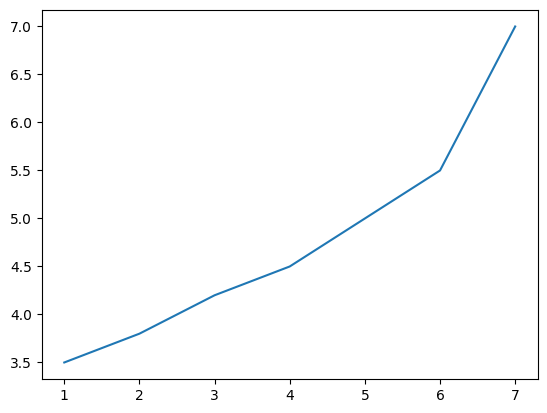

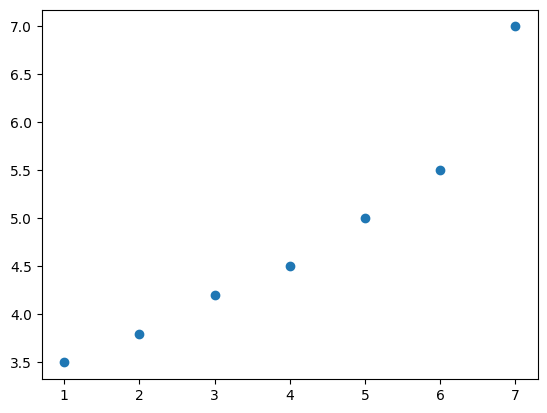

In [56]:
import matplotlib.pyplot as plt

x = [1, 2, 3, 4, 5, 6, 7]
y = [3.5, 3.8, 4.2, 4.5, 5, 5.5, 7]

plt.plot(x, y)
plt.show()

plt.scatter(x, y)
plt.show()

### Задание 11 (0.5 балла)

- С помощью функции `linspace` из библиотеки *Numpy* создайте массив `t` из 51  числа от 0 до 10 включительно.
- Создайте массив Numpy под названием `f`, содержащий косинусы элементов массива t.
- Постройте линейную диаграмму, используя массив `t` для координат по горизонтали,а массив `f` - для координат по вертикали. Линия графика должна быть зеленого цвета.
- Выведите название диаграммы - *График f(t)*.
- Также добавьте названия для горизонтальной оси - *Значения t* и для вертикальной - *Значения f*.
- Ограничьте график по оси `x` значениями 0.5 и 9.5, а по оси `y` - значениями -2.5 и 2.5.


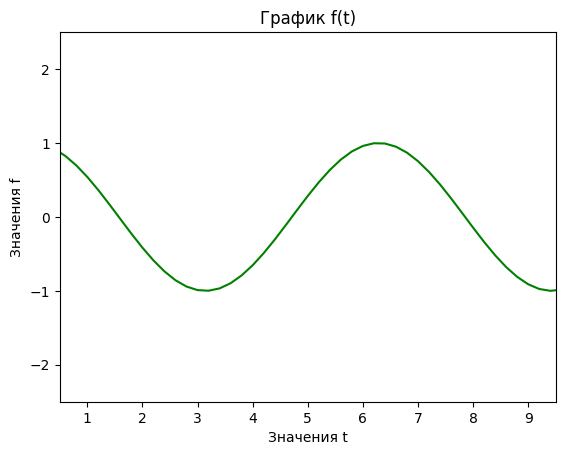

In [57]:
t = np.linspace(0, 10, 51) # сздаём массив t из 51 числа от 0 до 10 включительно
f = np.cos(t) # создаём массив f как косинусы элементов t
plt.plot(t, f, color='green') # строим линейную диаграмму

plt.title('График f(t)') # названия
plt.xlabel('Значения t')
plt.ylabel('Значения f')

plt.xlim(0.5, 9.5) # ограничения осей
plt.ylim(-2.5, 2.5)

plt.show()

### Задание 12 (0.5 балла)

- С помощью функции `linspace` библиотеки Numpy создайте массив `x` из 51 числа от -3 до 3 включительно.

- Создайте массивы `y1`, `y2`, `y3`, `y4` по следующим формулам:
  - y1 = x**2
  - y2 = 2 * x + 0.5
  - y3 = -3 * x - 1.5
  - y4 = sin(x)

- Используя функцию `subplots` модуля `matplotlib.pyplot`, создайте объект `matplotlib.figure.Figure` с названием *fig* и массив объектов `Axes` под названием *ax*, причем так, чтобы у вас было *4* отдельных графика в сетке, состоящей из двух строк и двух столбцов.  

- В каждом графике массив `x` используется для координат по горизонтали.  
В левом верхнем графике для координат по вертикали используйте `y1`,  
в правом верхнем - `y2`, в левом нижнем - `y3`, в правом нижнем - `y4`.  
- Дайте название графикам: *График y1*, *График y2* и т.д.  
- Для графика в левом верхнем углу установите границы по оси *x* от *-5* до *5*.  
- Установите размеры фигуры *8* дюймов по горизонтали и 6 дюймов по вертикали.  
Вертикальные и горизонтальные зазоры между графиками должны составлять *0.3*.  

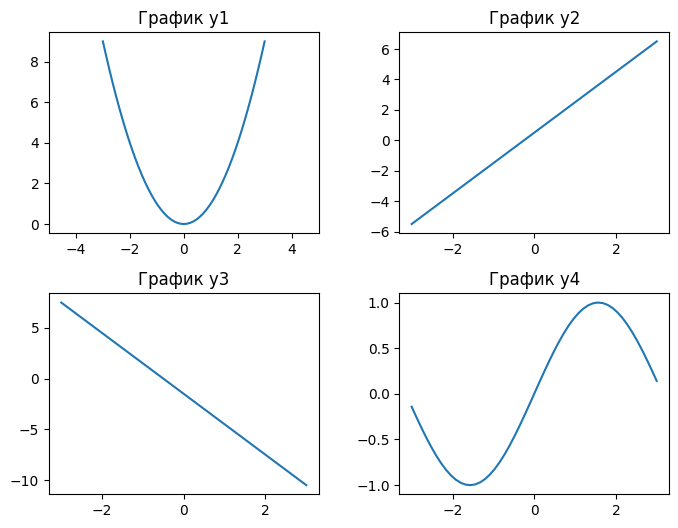

In [58]:
x = np.linspace(-3, 3, 51) # создаём массив x из 51 числа от -3 до 3 включительно
y1 = x**2  # вычисляем y1, y2, y3, y4
y2 = 2 * x + 0.5
y3 = -3 * x - 1.5
y4 = np.sin(x)

fig, ax = plt.subplots(2, 2, figsize=(8, 6)) # создаём фигуру с субплотами (2 строки, 2 столбца), размер 8x6 дюймов, зазоры 0.3
plt.subplots_adjust(hspace=0.3, wspace=0.3)

ax[0, 0].plot(x, y1) # левый верхний график (y1)
ax[0, 0].set_title('График y1')
ax[0, 0].set_xlim(-5, 5)

ax[0, 1].plot(x, y2) # правый верхний (y2)
ax[0, 1].set_title('График y2')

ax[1, 0].plot(x, y3) # левый нижний (y3)
ax[1, 0].set_title('График y3')

ax[1, 1].plot(x, y4) # правый нижний (y4)
ax[1, 1].set_title('График y4') 

plt.show()

### Задание 13 (0.5 балла)

В этом задании мы будем работать с датасетом, в котором приведены данные по мошенничеству с кредитными данными: Credit Card Fraud Detection (информация об авторах: Andrea Dal Pozzolo, Olivier Caelen, Reid A. Johnson and Gianluca Bontempi. Calibrating Probability with Undersampling for Unbalanced Classification. In Symposium on Computational Intelligence and Data Mining (CIDM), IEEE, 2015).

Данный датасет является примером несбалансированных данных, так как мошеннические операции с картами встречаются реже обычных.
Импортруйте библиотеку `Pandas`, а также используйте для графиков стиль *fivethirtyeight*.

Посчитайте с помощью метода `value_counts` количество наблюдений для каждого значения целевой переменной `Class` и примените к полученным данным метод `plot`, чтобы построить столбчатую диаграмму. Затем постройте такую же диаграмму, используя логарифмический масштаб.

На следующем графике постройте две гистограммы по значениям признака `V1` - одну для мошеннических транзакций (`Class` равен *1*) и другую - для обычных (`Class` равен *0*). Подберите значение аргумента `density` так, чтобы по вертикали графика было расположено не число наблюдений, а плотность распределения. Число бинов должно равняться *20* для обеих гистограмм, а коэффициент `alpha` сделайте равным *0.5*, чтобы гистограммы были полупрозрачными и не загораживали друг друга. Создайте легенду с двумя значениями: *Class 0* и *Class 1*. Гистограмма обычных транзакций должна быть серого цвета, а мошеннических - красного. Горизонтальной оси дайте название *Class*.

In [59]:
CREDIT_CARDS = 'https://www.dropbox.com/scl/fi/52uguzbixqi73kt3wlfy0/creditcard.csv?rlkey=l81ujgqku690hxcz72nz1ihi3&st=c7jd71e5&dl=1'

In [68]:

df = pd.read_csv('creditcard.csv', quotechar='"')
print(df.columns.tolist())


['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


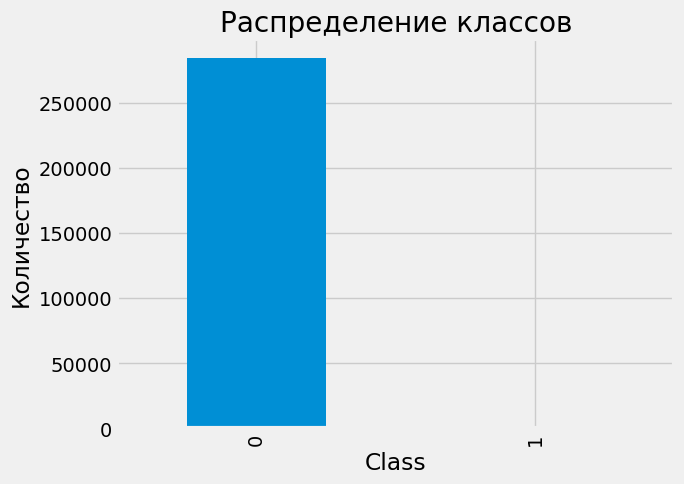

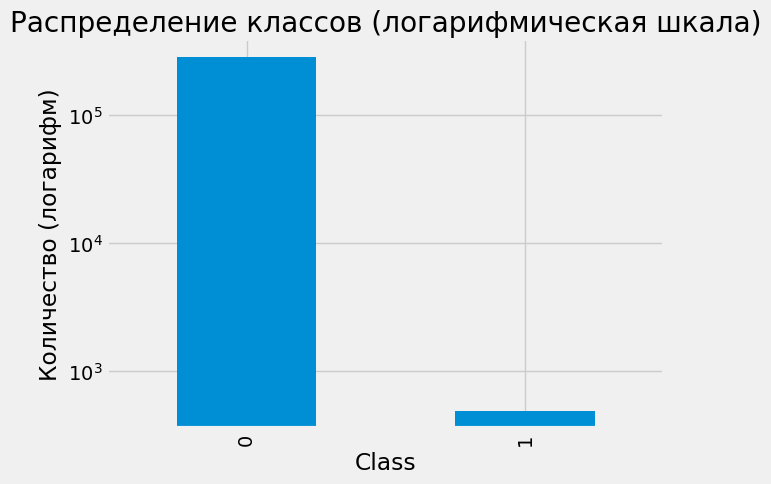

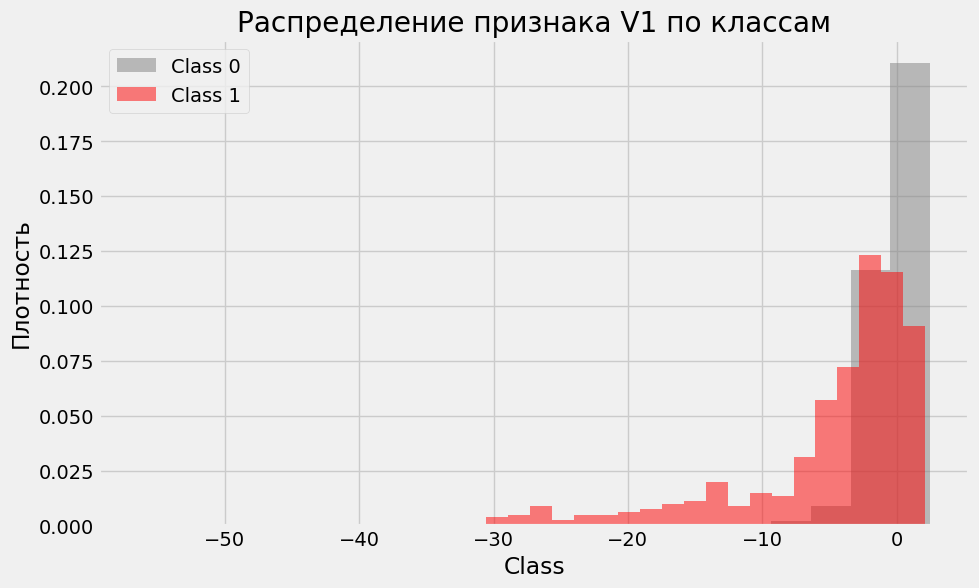

In [ ]:
plt.style.use('fivethirtyeight')

class_counts = df['Class'].value_counts() # 1. Столбчатая диаграмма количества наблюдений по классам
class_counts.plot(kind='bar')
plt.title('Распределение классов')
plt.xlabel('Class')
plt.ylabel('Количество')
plt.show()

class_counts.plot(kind='bar', logy=True) # 2. Столбчатая диаграмма с логарифмической шкалой
plt.title('Распределение классов (логарифмическая шкала)')
plt.xlabel('Class')
plt.ylabel('Количество (логарифм)')
plt.show()

plt.figure(figsize=(10, 6)) # 3. Гистограммы признака V1 по классам
plt.hist(df[df['Class'] == 0]['V1'], bins=20, density=True, alpha=0.5, color='gray', label='Class 0')
plt.hist(df[df['Class'] == 1]['V1'], bins=20, density=True, alpha=0.5, color='red', label='Class 1')
plt.xlabel('Class')
plt.ylabel('Плотность')
plt.title('Распределение признака V1 по классам')
plt.legend()
plt.show()

## Раздел 4. Визуализации в датасете кредитного скоринга

### О задании

Вы будете работать с задачей кредитного скоринга (оценка надёжности клиента). Предоставляются данные о 1000 клиентов, про которых известно около 20 признаков и положительная или отрицательная оценка в качестве кредитуемого. Эти данные нужно исследовать с помощью средств визуализации.

*Описание данных*:
https://www.rdocumentation.org/packages/evtree/versions/1.0-8/topics/GermanCredit

Каждый построенный график необходимо красиво оформить – для этого требуется как минимум указать его название, а также отметить, что изображено по каждой из осей.
**Также по каждому графику ожидается небольшой комментарий с выводами.**

*Функции, которые могут пригодиться при оформлении графиков: `.show()`, `.title()`, `.xlabel()`, `.ylabel()`*

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [72]:

GERMAN_CREDIT = 'https://github.com/evgpat/datasets/raw/refs/heads/main/german_credit.csv'

In [73]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context
df = pd.read_csv(GERMAN_CREDIT)

In [74]:
print(df.columns.tolist())

['status', 'duration', 'credit_history', 'purpose', 'amount', 'savings', 'employment_duration', 'installment_rate', 'personal_status_sex', 'other_debtors', 'present_residence', 'property', 'age', 'other_installment_plans', 'housing', 'number_credits', 'job', 'people_liable', 'telephone', 'foreign_worker', 'credit_risk']


### Задание 14 (0.5 балла)

Используя `numpy` и `matplotlib`, начнём с тренировки: постройте график функций $sin(x)$ и $cos(x)$ на интервале от $-\pi$ до $\pi$, используя 100 точек. Добавьте легенду и сетку. Используйте для линий разные цвета, одна из них пусть будет пунктирной. Результат в этом и следующих заданиях на построение графиков должен получиться максимально схожим с картинкой. Содержание подписей не должно обязательно совпадать, однако осмысленные подписи должны присутствовать на графиках.

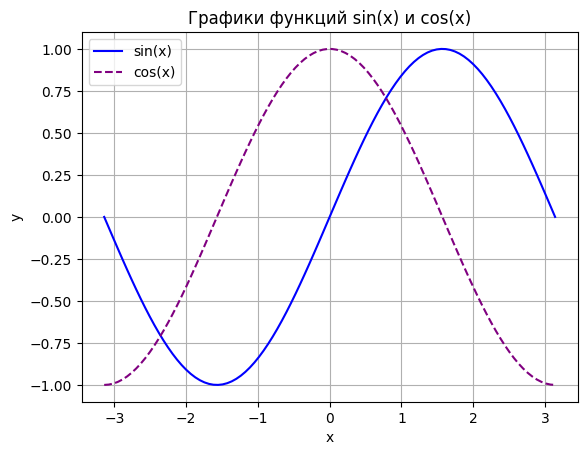

ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/Users/maksimbelov/python/.venv/lib/python3.10/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
  File "/Users/maksimbelov/python/.venv/lib/python3.10/site-packages/ipykernel/kernelbase.py", line 348, in dispatch_control
    await self.process_control(msg)
  File "/Users/maksimbelov/python/.venv/lib/python3.10/site-packages/ipykernel/kernelbase.py", line 354, in process_control
    idents, msg = self.session.feed_identities(msg, copy=False)
  File "/Users/maksimbelov/python/.venv/lib/python3.10/site-packages/jupyter_client/session.py", line 998, in feed_identities
    raise ValueError(msg)
ValueError: DELIM not in msg_list
ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/Users/maksimbelov/python/.venv/lib/python3.10/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.resu

In [ ]:
x = np.linspace(-np.pi, np.pi, 100) # Генерируем 100 точек от -pi до pi

y_sin = np.sin(x) # Вычисляем значения sin и cos
y_cos = np.cos(x)

plt.plot(x, y_sin, color='blue', linestyle='-', label='sin(x)') # Строим графики
plt.plot(x, y_cos, color='purple', linestyle='--', label='cos(x)')

plt.xlabel('x') # Подписи и заголовок
plt.ylabel('y')
plt.title('Графики функций sin(x) и cos(x)')

plt.legend() # Легенда и сетка
plt.grid(True)

plt.show()

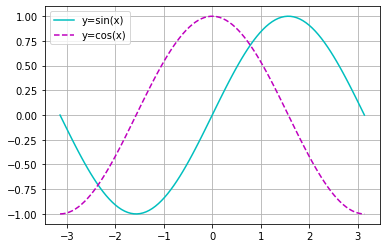

In [ ]:
# то что должно получиться

### Задание 15 (0.5 балла)

Прочитайте средствами pandas файл с данными кредитного скоринга. Рассмотрите сравнительное количество положительных и отрицательных кейсов в зависимости от размера текущего счёта. Постройте зеркальные горизонтальные гистограммы.

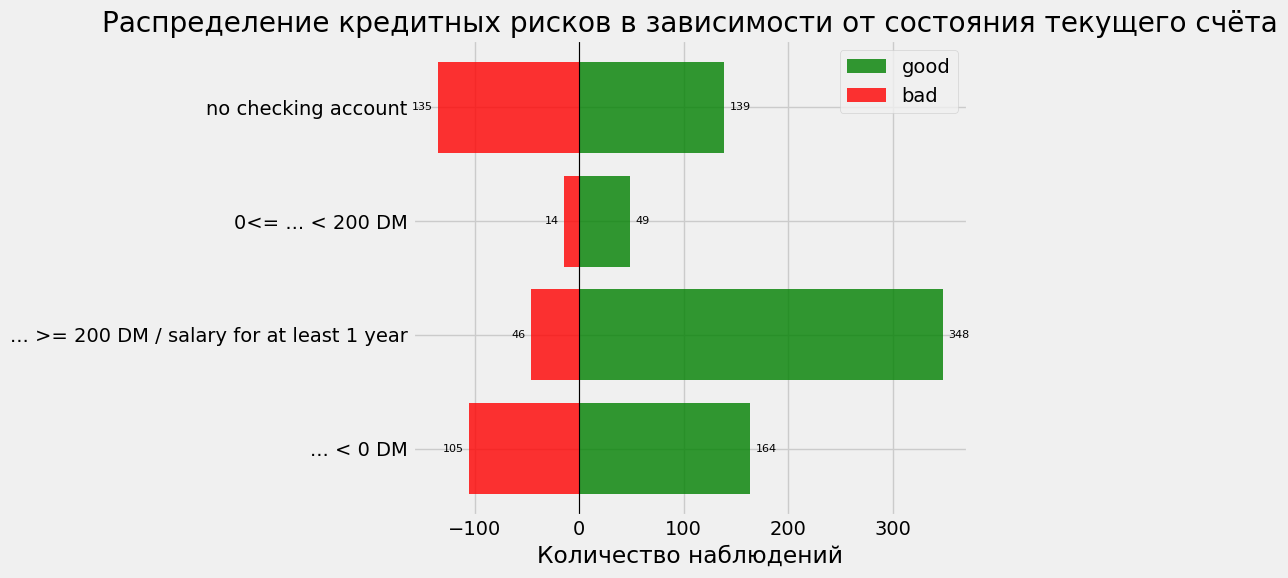

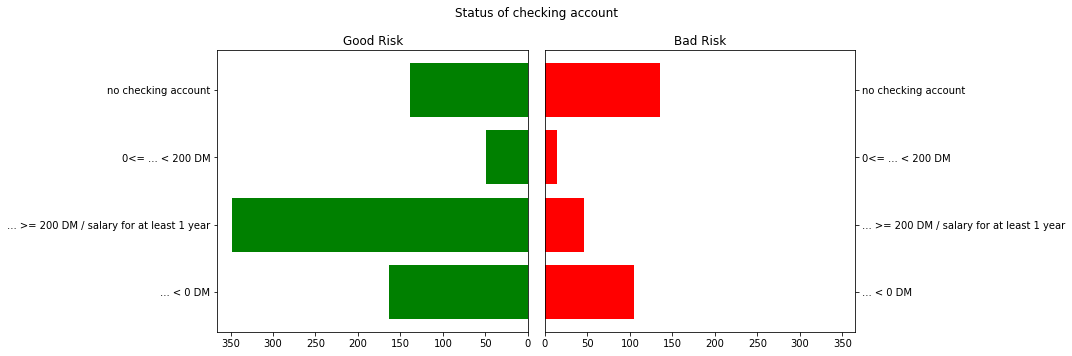

In [ ]:
# то что должно получиться

### Задание 16 (0.5 балла)

In [ ]:
import seaborn as sns

Теперь постройте гистограмму для сравнения количества положительных и отрицательных кейсов в зависимости от размера сберегательного счёта с помощью seaborn. Какой способ вам больше нравится с точки зрения трудоёмкости написания кода? А с точки зрения восприятия результата?

ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/Users/maksimbelov/python/.venv/lib/python3.10/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
  File "/Users/maksimbelov/python/.venv/lib/python3.10/site-packages/ipykernel/kernelbase.py", line 348, in dispatch_control
    await self.process_control(msg)
  File "/Users/maksimbelov/python/.venv/lib/python3.10/site-packages/ipykernel/kernelbase.py", line 354, in process_control
    idents, msg = self.session.feed_identities(msg, copy=False)
  File "/Users/maksimbelov/python/.venv/lib/python3.10/site-packages/jupyter_client/session.py", line 998, in feed_identities
    raise ValueError(msg)
ValueError: DELIM not in msg_list
ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/Users/maksimbelov/python/.venv/lib/python3.10/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.resu

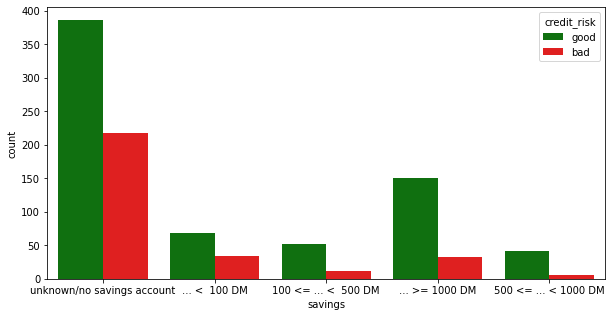

In [ ]:
# то что должно получиться

**ВАШ ОТВЕТ**  
...

### Задание 17 (0.5 балла)

seaborn легко позволяет добавить ещё больше информации на один график. Для каждого размера сберегательного счёта мы можем оценить не только количество положительных и отрицательных кейсов, но и их распределение по возрасту, например. Постройте подходящую для этого визуализацию.

In [ ]:
# ваш код здесь
...

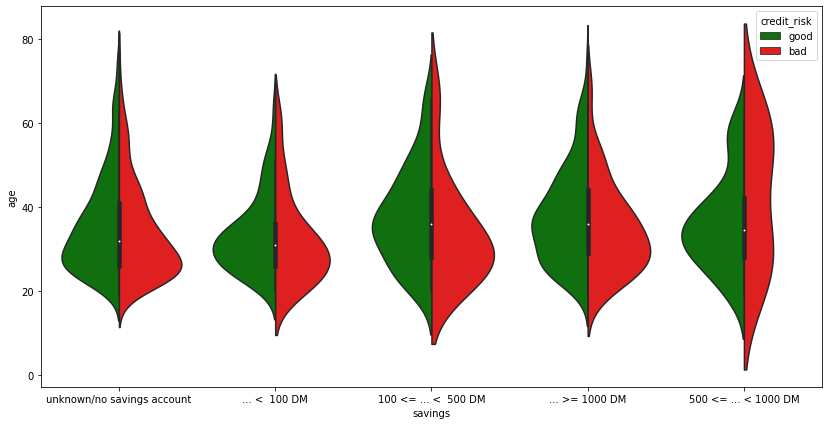

In [ ]:
# то что должно получиться

### Задание 18 (0.5 балла)

Заканчивая с гистограммами, посмотрим на распределение положительных и отрицательных кейсов по возрастам, разместив их друг над другом. Добавим распределение всех взятых кредитов.

In [ ]:
# ваш код здесь
...

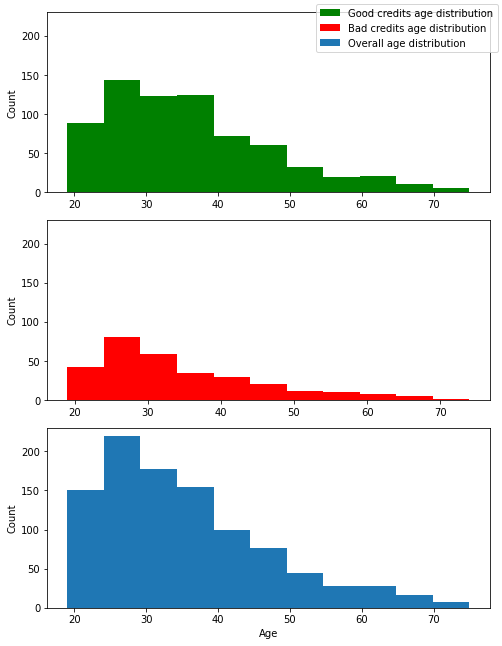

In [ ]:
# то что должно получиться

### Задание 19 (0.5 балла)

Не менее полезной иногда может быть диаграмма рассеяния. Постройте такую диаграмму с продолжительностью и размерами кредитов в качестве осей. Обозначьте положительные и отрицательные кейсы разными цветами.

In [ ]:
# ваш код здесь
...

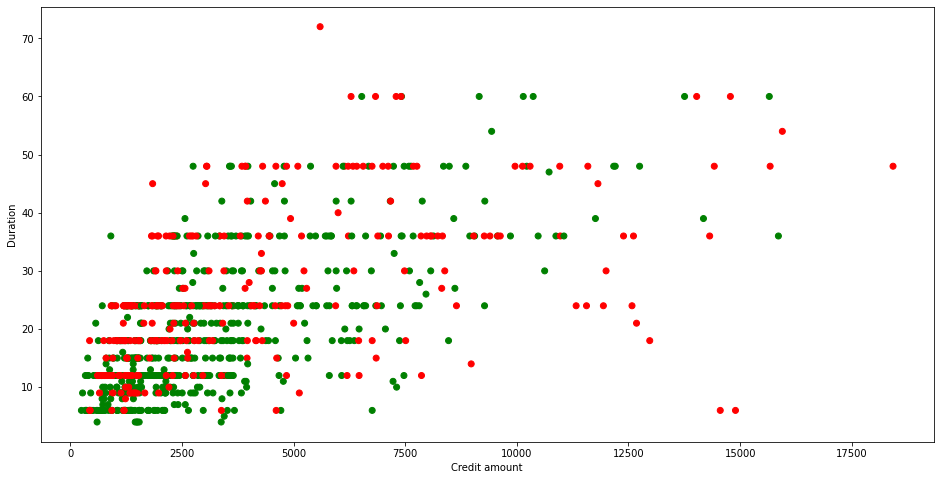

In [ ]:
# то что должно получиться

### Задание 20* (1 балл)

Продвинемся глубже. Постройте 3D версию диаграммы рассеяния, добавив ось с возрастом.

In [ ]:
# ваш код здесь
...

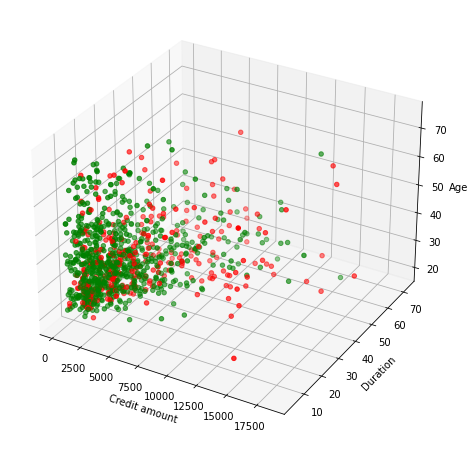

In [ ]:
# то что должно получиться

Что вы можете сказать о сравнении 3D- и 2D-визуализаций? Какие вы видите в них преимущества и недостатки?

Какие выводы с точки зрения бизнеса можно сделать из полученного графика?

**ВАШ ОТВЕТ**  
...

## Раздел 5. Визуализации в датасете Netflix

In [ ]:
NETFLIX_TITLES = 'https://github.com/evgpat/datasets/raw/refs/heads/main/netflix_titles.csv'

### Задание 21  (0.5 балла)

Прочитайте средствами pandas файл с данными Netflix. Посчитайте количество пропусков (NaN) в колонке `director`. Постройте столбчатую диаграмму, которая показывает 5 стран, в которых наибольшее количество фильмов имеет пропуски в столбце director.

Добавьте на диаграмму:

- Заголовок жирным шрифтом
- Подписи осей

In [ ]:
# your code here

### Задание 22 (0.5 балла)

Постройте pie chart (круговую диаграмму), показывающую 5 стран, в которых произвели больше всего фильмов.

Добавьте на диаграмму:

+ Заголовок (Тип шрифта: ``family = 'monospace'``, насыщенность: ``fontweight='bold'``)
+ Название стран (Тип шрифта: ``family = 'monospace'``)
+ Подписи значений (%) (Тип шрифта: ``family = 'monospace'``)
+ Выберите стиль для диаграммы pastel c помощью библиотеки ``seaborn``

```colors = sns.color_palette('pastel')[0:5]```

In [ ]:
# your code here

### Задание 23 (0.5 балла)

Постройте subplots, где на первом графике будет круговая диаграмма, показывающая долю фильмов каждого рейтинга *(rating)*, а на втором столбчатая диаграмма, показывающая 3 страны, в которых было снято больше всего фильмов с рейтингом TV-MA.

*Если фильмов в каких-то рейтингах меньше 50, то их в график брать не нужно*

Добавьте на диаграммы:

+ Заголовки (можно жирным)

Круговая диаграмма:
+ Подписи значений абсолютные

Столбчатая диаграммма:
+ Сделайте так, чтобы ось Y была справа
+ Добавьте подпись «Количество фильмов» к оси Y и уберите подпись к оси X
+ Оставьте видимыми только правую и нижнюю границы

In [ ]:
# your code here

### Задание 24 (1 балл)

Преобразуйте колонку `date_added` в datetime. Создайте новые столбцы month и year из преобразованного столбца. Постройте линейный график: сколько в среднем фильмов было снято в каждый из месяцев.

Добавьте на график:

+ Заголовок жирным шрифтом
+ Подписи осей
+ Маркеры на точках перегиба
+ Настройте ось X: ось начинается с 1 заканчивается 12, шаг 1

In [ ]:
# your code here

### Задание 25 (1 балл)

Постройте линеный график, в какие годы (столбец year, который вы создали в задании 4) сколько фильмов было снято.

Добавьте на график:

+ Заголовок жирным шрифтом
+ Подписи осей
+ Измените цвет линии графика и сделайте ее пунктиром
+ Решетку на фон

In [ ]:
# your code here

### Задание 26 (1 балл)

Будем работать со столбцом duration. Одни данные даны в минутах (для фильмов (Movie)), а другие в сезонах (для сериалов (TV shows)). Создайте два новых столбца min (для тех, у кого продолжительность в минутах) и season (для тех, у кого продолжительность в сезонах), в которых будут извлечены данные из столбца duration.

Постройте subplots, где на первом графике гистрограмма распределения продолжительности фильмов, а на втором – гистрограмма распределения продолжительности сериалов.

Добавьте на графики:

+ Заголовки жирным шрифтом
+ Подписи осей

In [ ]:
# your code here

### Задание 27 (0.5 балла)

Постройте ящик с усами (box plot) по продолжительности фильмов (Movies). Визуально проинтерпретируйте его.

In [ ]:
# your code here

**ВАШ ОТВЕТ**  
...

### Задание 28 (1 балл)

Постройте при помощи библиотеки plotly интерактивную столбчатую диаграмму, которая сравнивает среднюю продолжительность фильмов и сериалов за каждый год, начиная с 2000.

In [ ]:
# your code here

## Заключительная часть

Надеемся, вы честно проделали все пункты, а не просто пролистали досюда. Теперь можно отдохнуть и похвалить себя. Но пожалуйста, не стоит награждать себя до того, как закончите работать над домашкой :)


Поделитесь впечатлениями о задании:

    (ваши эмоции от домашней работы)

P.S Удачного кодинга!  
Пейте черничный латте, пишите красивый Python!!